In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import fetch_california_housing

house=fetch_california_housing()
house.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
house.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [23]:
print(house.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
house.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [6]:
house.target_names

['MedHouseVal']

In [7]:
X,y=fetch_california_housing(return_X_y=True)
# y is target name and X is the features in the dataset

In [8]:
from sklearn.neighbors import KNeighborsRegressor
mod=KNeighborsRegressor()
mod.fit(X,y)
pred=mod.predict(X)
mod.score(X,y)
#  score is used to tell how well the model is 

0.471118594496435

In [9]:
# from sklearn.linear_model import LinearRegression
# mod=LinearRegression()
# mod.fit(X,y)
# mod.predict(X)
# mod.score(X,y)

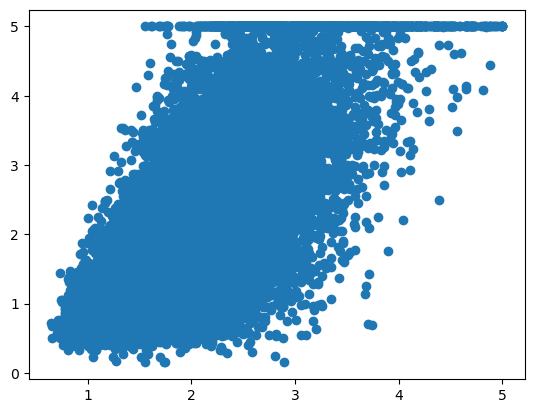

In [10]:
plt.scatter(pred,y)

In [11]:
# now instead of doing the knn sepearetly we can create a pipeline where it contains the scaling and knn
from sklearn.preprocessing import StandardScaler
# Standard scaler will find the mean and variance of the col and uses the 
# formulae (x-mean)/sqrt(var)
from sklearn.pipeline import Pipeline
pipe=Pipeline([
    ("scale",StandardScaler()),("model",KNeighborsRegressor())
])
pipe.fit(X,y)


,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [15]:
pred=pipe.predict(X)

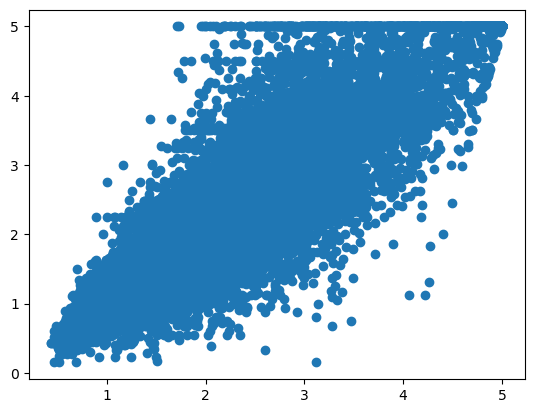

In [14]:
plt.scatter(pred,y)

In [16]:
# now we will split the dataset into 3 parts and make 3 copies of the 
# dataset which is divided into 3 peices
# so that we use only 2 pieces to make the model learn and other peice is for test
# so let us convert this pipeline into a grid search
from sklearn.model_selection import GridSearchCV


pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [17]:
GridSearchCV(estimator=pipe,
             param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,10]},
             cv=3)
# cv means cross validation 

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [18]:
model=GridSearchCV(estimator=pipe,
             param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,10]},
             cv=3)
# cv means cross validation 

In [19]:
model.fit(X,y)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [21]:
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.029824,0.012960,0.283783,0.046879,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.022928,0.003602,0.360168,0.040972,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.020068,0.002415,0.360007,0.051625,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.022600,0.000969,0.431747,0.063557,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.022651,0.007290,0.385949,0.032947,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.021137,0.002067,0.389551,0.036745,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.019715,0.001509,0.394505,0.021123,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.020113,0.003771,0.374847,0.025246,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.017858,0.001055,0.373298,0.025258,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.018351,0.001646,0.385520,0.025652,10,{'model__n_neighbors': 10},0.573760,0.595831,0.532973,0.567522,0.026038,1
